<a href="https://colab.research.google.com/github/sofiahuang2225-prog/python-DM-group-k/blob/main/ML_RF_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install flaml
from flaml import AutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 6.2 MB/s eta 0:00:00


In [3]:
df=pd.read_csv('final_HR-Employee-Attrition.csv')

In [4]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Attrition                          1470 non-null   bool   
 1   DistanceFromHome                   1470 non-null   int64  
 2   Education                          1470 non-null   int64  
 3   EnvironmentSatisfaction            1470 non-null   int64  
 4   JobInvolvement                     1470 non-null   int64  
 5   JobSatisfaction                    1470 non-null   int64  
 6   MonthlyIncome                      1470 non-null   int64  
 7   NumCompaniesWorked                 1470 non-null   int64  
 8   OverTime                           1470 non-null   bool   
 9   PerformanceRating                  1470 non-null   int64  
 10  RelationshipSatisfaction           1470 non-null   int64  
 11  StockOptionLevel                   1470 non-null   int64

,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,OverTime,PerformanceRating,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,True,1,2,2,3,4,5993,8,True,3,...,False,False,False,False,False,False,True,False,False,True
1,False,8,1,3,2,2,5130,1,False,4,...,False,False,False,False,False,True,False,False,True,False
2,True,2,2,4,2,3,2090,6,True,3,...,False,True,False,False,False,False,False,False,False,True
3,False,3,4,4,3,3,2909,1,True,3,...,False,False,False,False,False,True,False,False,True,False
4,False,2,1,1,3,2,3468,9,False,3,...,False,True,False,False,False,False,False,False,True,False
5,False,2,2,4,3,4,3068,0,False,3,...,False,True,False,False,False,False,False,False,False,True
6,False,3,3,3,4,1,2670,4,True,4,...,False,True,False,False,False,False,False,False,True,False
7,False,24,1,4,3,3,2693,1,False,4,...,False,True,False,False,False,False,False,False,False,False
8,False,23,3,4,2,3,9526,0,False,4,...,False,False,False,True,False,False,False,False,False,True
9,False,27,3,3,3,3,5237,6,False,3,...,False,False,False,False,False,False,False,False,True,False


### 2. Training Model with FLAML

###2.1 Find best training/Test data split ratio

In [5]:
# 1.確保目標變數 (Y) 轉換為數值 0 和 1 (True->1, False->0)
df['Attrition'] = df['Attrition'].astype(int)

#2. 將布林形態特徵也都轉為(0/1)
# 假設 df 中有數個布林欄位
bool_cols = df.select_dtypes(include=['bool']).columns
# 直接將這些欄位轉成整數 0/1
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Standardisation
scale_standard = StandardScaler()
X = scale_standard.fit_transform(X)


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



--- 搭配不同資料分割比例，優化 Logistic Regression ---


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


> 測試集比例 10%: Train(CV) F1 = 0.5092, Test F1 = 0.5000


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


...

> 測試集比例 60%: Train(CV) F1 = 0.5222, Test F1 = 0.4510


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


> 測試集比例 70%: Train(CV) F1 = 0.4694, Test F1 = 0.4350


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


> 測試集比例 80%: Train(CV) F1 = 0.4918, Test F1 = 0.4715
> 測試集比例 90%: Train(CV) F1 = 0.4884, Test F1 = 0.3800


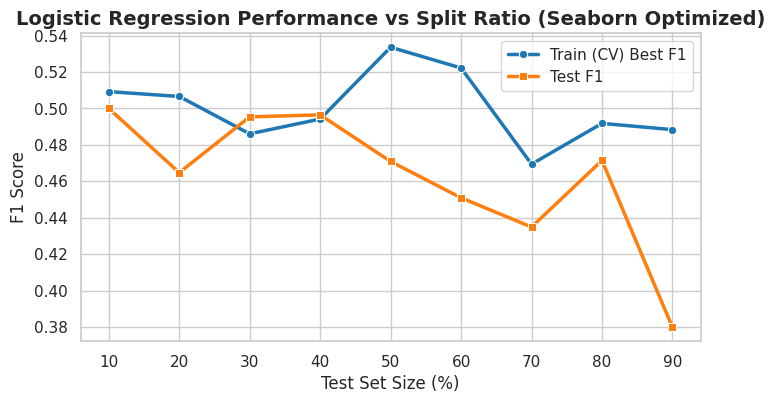

In [7]:
# ==========================================
# 步驟 A：用 FLAML 自動優化 Logistic Regression (不同分割比例實驗)
# ==========================================
print("\n--- 搭配不同資料分割比例，優化 Logistic Regression ---")

import copy
import seaborn as sns
sns.set_theme(style="whitegrid")

automl_lr = AutoML()
settings_lr = {
    "time_budget": 60,
    "metric": 'f1',
    "task": 'classification',
    "estimator_list": ['lrl1', 'lrl2'],
    "custom_hp": {
        "lrl1": {"class_weight": {"domain": "balanced"}},
        "lrl2": {"class_weight": {"domain": "balanced"}}
    },
    "verbose": 0
}

ratio_values = [i for i in range(10, 100, 10)]
train_f1_scores_lr = []
test_f1_scores_lr = []

automl_lr_best = None
best_overall_f1_lr = -1

for i in ratio_values:
    test_size_ratio = i / 100
    X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(
        X, y, test_size=test_size_ratio, random_state=71, stratify=y
    )

    automl_lr.fit(X_train=X_train_loop, y_train=y_train_loop, **settings_lr)

    best_train_f1 = 1 - automl_lr.best_loss
    train_f1_scores_lr.append(best_train_f1)

    y_pred_test = automl_lr.predict(X_test_loop)
    current_test_f1 = f1_score(y_test_loop, y_pred_test)
    test_f1_scores_lr.append(current_test_f1)

    if current_test_f1 > best_overall_f1_lr:
        best_overall_f1_lr = current_test_f1
        automl_lr_best = copy.deepcopy(automl_lr)
        best_ratio_lr = i/100

    print(f"> 測試集比例 {i}%: Train(CV) F1 = {best_train_f1:.4f}, Test F1 = {current_test_f1:.4f}")

# 美化繪圖
plt.figure(figsize=(8, 4))
sns.lineplot(x=ratio_values, y=train_f1_scores_lr, marker='o', label='Train (CV) Best F1', color='#1f77b4', linewidth=2.5)
sns.lineplot(x=ratio_values, y=test_f1_scores_lr, marker='s', label='Test F1', color='#ff7f0e', linewidth=2.5)

plt.xlabel('Test Set Size (%)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Logistic Regression Performance vs Split Ratio (Seaborn Optimized)', fontsize=14, fontweight='bold')
plt.legend(frameon=True, facecolor='white')
plt.show()


--- 搭配不同資料分割比例，優化 Random Forest ---
> 測試集比例 10%: Train(CV) F1 = 0.5171, Test F1 = 0.5574
> 測試集比例 20%: Train(CV) F1 = 0.5185, Test F1 = 0.4906
> 測試集比例 30%: Train(CV) F1 = 0.5083, Test F1 = 0.5053
> 測試集比例 40%: Train(CV) F1 = 0.4978, Test F1 = 0.5208
> 測試集比例 50%: Train(CV) F1 = 0.5074, Test F1 = 0.5358
> 測試集比例 60%: Train(CV) F1 = 0.5990, Test F1 = 0.4655
> 測試集比例 70%: Train(CV) F1 = 0.4901, Test F1 = 0.4490
> 測試集比例 80%: Train(CV) F1 = 0.4975, Test F1 = 0.3935
> 測試集比例 90%: Train(CV) F1 = 0.5670, Test F1 = 0.3812


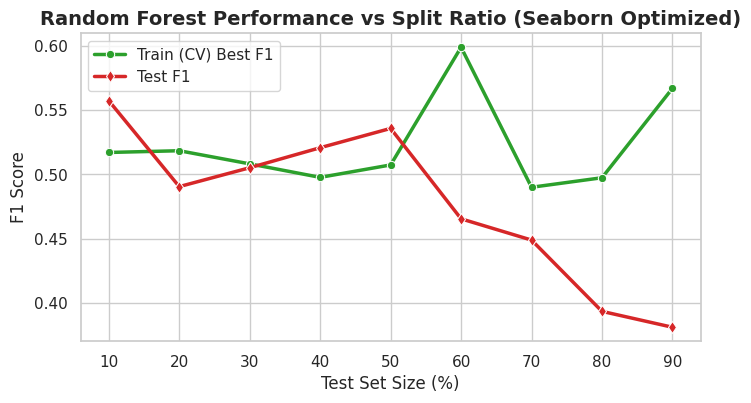

In [8]:
# ==========================================
# 步驟 B：用 FLAML 自動優化 Random Forest (不同分割比例實驗)
# ==========================================
print("\n--- 搭配不同資料分割比例，優化 Random Forest ---")

import copy
import seaborn as sns
sns.set_theme(style="whitegrid")

automl_rf = AutoML()
settings_rf = {
    "time_budget": 120,
    "metric": 'f1',
    "task": 'classification',
    "estimator_list": ['rf'],
    "custom_hp": {
        "rf": {
            "class_weight": {"domain": "balanced"}
        }
    },
    "verbose": 0
}

ratio_values = [i for i in range(10, 100, 10)]
train_f1_scores = []
test_f1_scores = []

automl_rf_best = None
best_overall_f1 = -1

for i in ratio_values:
    test_size_ratio = i / 100
    X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(
        X, y, test_size=test_size_ratio, random_state=71, stratify=y
    )

    automl_rf.fit(X_train=X_train_loop, y_train=y_train_loop, **settings_rf)

    best_train_f1 = 1 - automl_rf.best_loss
    train_f1_scores.append(best_train_f1)

    y_pred_test = automl_rf.predict(X_test_loop)
    current_test_f1 = f1_score(y_test_loop, y_pred_test)
    test_f1_scores.append(current_test_f1)

    if current_test_f1 > best_overall_f1:
        best_overall_f1 = current_test_f1
        automl_rf_best = copy.deepcopy(automl_rf)
        best_ratio_rf = i/100

    print(f"> 測試集比例 {i}%: Train(CV) F1 = {best_train_f1:.4f}, Test F1 = {current_test_f1:.4f}")

# 美化繪圖
plt.figure(figsize=(8, 4))
sns.lineplot(x=ratio_values, y=train_f1_scores, marker='o', label='Train (CV) Best F1', color='#2ca02c', linewidth=2.5)
sns.lineplot(x=ratio_values, y=test_f1_scores, marker='d', label='Test F1', color='#d62728', linewidth=2.5)

plt.xlabel('Test Set Size (%)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Random Forest Performance vs Split Ratio (Seaborn Optimized)', fontsize=14, fontweight='bold')
plt.legend(frameon=True, facecolor='white')
plt.show()

In [9]:
# ==========================================
# 3. 輸出兩者的最佳表現比較
# ==========================================
print("\n=== FLAML 最佳化結果比較 ===")
print(f"Logistic Regression 最佳超參數: {automl_lr_best.best_config}")
print(f"Logistic Regression 在訓練集(驗證)的最佳 F1: {1 - automl_lr_best.best_loss:.4f}")
print(f"Logistic Regression 的最佳資料分拆比例：{best_ratio_lr}")

print(f"\nRandom Forest 最佳超參數: {automl_rf_best.best_config}")
print(f"Random Forest 在訓練集(驗證)的最佳 F1: {1 - automl_rf_best.best_loss:.4f}")
print(f"Random Forest 的最佳資料分拆比例：{best_ratio_rf}")


=== FLAML 最佳化結果比較 ===
Logistic Regression 最佳超參數: {'C': np.float64(0.36301970966721453), 'class_weight': 'balanced'}
Logistic Regression 在訓練集(驗證)的最佳 F1: 0.5092
Logistic Regression 的最佳資料分拆比例：0.1

Random Forest 最佳超參數: {'n_estimators': 190, 'max_features': np.float64(0.12267797076604801), 'max_leaves': 13, 'criterion': np.str_('gini'), 'class_weight': 'balanced'}
Random Forest 在訓練集(驗證)的最佳 F1: 0.5171
Random Forest 的最佳資料分拆比例：0.1


### 2.2 AutoML with best training/test ratio of dataset

In [10]:
# 1. 切分訓練集與測試集
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=best_ratio_lr, random_state=71, stratify=y)
# 2. 初始化 FLAML
automl_lr = AutoML()

# 3. 關鍵設定：透過 custom_hp 固定邏輯斯迴歸的類別權重
settings_lr = {
    "time_budget": 300,            # 自動調參時間（秒）
    "metric": 'f1',               # 優化目標：F1-score
    "task": 'classification',     # 分類任務
    "estimator_list": ['lrl1', 'lrl2'], # 強制只訓練 L1/L2 Logistic Regression

    # 🔥 核心設定：為 Logistic Regression 加入 class_weight='balanced'
    "custom_hp": {
        "lrl1": {
            "class_weight": {
                "domain": "balanced"  # 鎖定 L1 版本的權重為 balanced
            }
        },
        "lrl2": {
            "class_weight": {
                "domain": "balanced"  # 鎖定 L2 版本的權重為 balanced
            }
        }
    },
    "log_file_name": 'hr_logistic_regression_automl.log',
}

# 5. 開始自動化訓練與調參
print("--- 開始執行 Logistic Regression (已設定 Class Weight) 自動優化 ---")
automl_lr.fit(X_train=X_train_lr, y_train=y_train_lr, **settings_lr)

# 6. 檢視最佳結果
print("\n=== 優化完成 ===")
print(f"最佳模型演算法: {automl_lr.best_estimator}")
print(f"最佳超參數組合: {automl_lr.best_config}")
print(f"訓練/驗證集最佳 F1-score: {1 - automl_lr.best_loss:.4f}")

--- 開始執行 Logistic Regression (已設定 Class Weight) 自動優化 ---
[flaml.automl.logger: 05-21 10:18:23] {2375} INFO - task = classification
[flaml.automl.logger: 05-21 10:18:23] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-21 10:18:23] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 05-21 10:18:23] {2606} INFO - List of ML learners in AutoML Run: ['lrl1', 'lrl2']
[flaml.automl.logger: 05-21 10:18:23] {2911} INFO - iteration 0, current learner lrl1


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-21 10:18:23] {3046} INFO - Estimated sufficient time budget=4124s. Estimated necessary time budget=4s.
[flaml.automl.logger: 05-21 10:18:23] {3097} INFO -  at 0.4s,	estimator lrl1's best error=4.9647e-01,	best estimator lrl1's best error=4.9647e-01
[flaml.automl.logger: 05-21 10:18:23] {2911} INFO - iteration 1, current learner lrl2


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-21 10:18:27] {3097} INFO -  at 4.3s,	estimator lrl2's best error=4.9885e-01,	best estimator lrl1's best error=4.9647e-01
[flaml.automl.logger: 05-21 10:18:27] {2911} INFO - iteration 2, current learner lrl1
[flaml.automl.logger: 05-21 10:18:28] {3097} INFO -  at 4.7s,	estimator lrl1's best error=4.9647e-01,	best estimator lrl1's best error=4.9647e-01
[flaml.automl.logger: 05-21 10:18:28] {2911} INFO - iteration 3, current learner lrl1
[flaml.automl.logger: 05-21 10:18:28] {3097} INFO -  at 5.2s,	estimator lrl1's best error=4.9647e-01,	best estimator lrl1's best error=4.9647e-01
[flaml.automl.logger: 05-21 10:18:28] {2911} INFO - iteration 4, current learner lrl1
[flaml.automl.logger: 05-21 10:18:28] {3097} INFO -  at 5.5s,	estimator lrl1's best error=4.9159e-01,	best estimator lrl1's best error=4.9159e-01
[flaml.automl.logger: 05-21 10:18:28] {2911} INFO - iteration 5, current learner lrl1
[flaml.automl.logger: 05-21 10:18:29] {3097} INFO -  at 5.9s,	estimator 

In [11]:
# 1. 切分訓練集與測試集
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=best_ratio_rf, random_state=71, stratify=y)
# 建立 FLAML 實例
automl_rf = AutoML()

# 定義設定
settings_rf = {
    "time_budget": 600,
    "metric": 'f1',            # 1. 考試標準：追求最高的 F1-score
    "task": 'classification',
    "estimator_list": ['rf'],  # 強制隨機森林

    # 2. 讀書策略：強制鎖定底層模型的 class_weight 為 'balanced'
    "custom_hp": {
        "rf": {
            "class_weight": {
                "domain": "balanced"  # 強制固定為 balanced，不讓 FLAML 去隨機嘗試 None
            }
        }
    },
    "log_file_name": 'hr_rf_automl.log',
}

# 開始訓練
automl_rf.fit(X_train=X_train_rf, y_train=y_train_rf, **settings_rf)

[flaml.automl.logger: 05-21 10:25:08] {2375} INFO - task = classification
[flaml.automl.logger: 05-21 10:25:08] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-21 10:25:08] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 05-21 10:25:08] {2606} INFO - List of ML learners in AutoML Run: ['rf']
[flaml.automl.logger: 05-21 10:25:08] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 05-21 10:25:09] {3046} INFO - Estimated sufficient time budget=3272s. Estimated necessary time budget=3s.
[flaml.automl.logger: 05-21 10:25:09] {3097} INFO -  at 0.4s,	estimator rf's best error=6.4070e-01,	best estimator rf's best error=6.4070e-01
[flaml.automl.logger: 05-21 10:25:09] {2911} INFO - iteration 1, current learner rf
[flaml.automl.logger: 05-21 10:25:09] {3097} INFO -  at 0.7s,	estimator rf's best error=6.3801e-01,	best estimator rf's best error=6.3801e-01
[flaml.automl.logger: 05-21 10:25:09] {2911} INFO - iteration 2, current learner rf
[flaml.autom

### 3. 測試集性能評估與比較

首先，我們將從 FLAML 獲得的最佳模型中，對測試集進行預測並計算各項性能指標 (Accuracy, Precision, Recall, F1-score, ROC AUC)。


In [22]:

# 對測試集進行預測
y_pred_lr = automl_lr.predict(X_test_lr)
y_pred_rf = automl_rf.predict(X_test_rf)

# 對測試集進行概率預測 (用於 ROC AUC)
y_pred_proba_lr = automl_lr.predict_proba(X_test_lr)[:, 1]
y_pred_proba_rf = automl_rf.predict_proba(X_test_rf)[:, 1]


# 函數來計算和打印所有評估指標
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\n--- {model_name} 測試集表現 ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

# 評估 Logistic Regression
metrics_lr = evaluate_model(y_test_lr, y_pred_lr, y_pred_proba_lr, "Logistic Regression")

# 評估 Random Forest
metrics_rf = evaluate_model(y_test_rf, y_pred_rf, y_pred_proba_rf, "Random Forest")


--- Logistic Regression 測試集表現 ---
Accuracy: 0.7415
Precision: 0.3600
Recall: 0.7500
F1-score: 0.4865
ROC AUC: 0.8238

--- Random Forest 測試集表現 ---
Accuracy: 0.8095
Precision: 0.4474
Recall: 0.7083
F1-score: 0.5484
ROC AUC: 0.8780


### 3.1 ROC 曲線比較

除了混淆矩陣，ROC 曲線 (Receiver Operating Characteristic curve) 能更全面地展示模型在不同閾值下的分類能力。

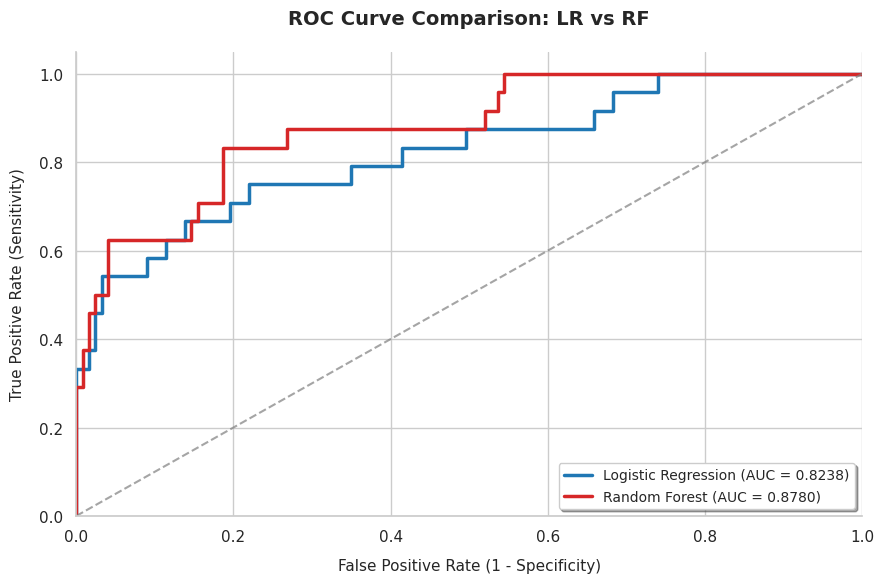

In [23]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 1. 設定 Seaborn 風格與美化參數
sns.set_theme(style="whitegrid")

# 2. 計算 ROC 曲線數據 (LR & RF)
fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 3. 建立繪圖物件，增加 DPI 提高解析度
plt.figure(figsize=(9, 6), dpi=100)

# 4. 使用 Seaborn 色彩調性繪製曲線
plt.plot(fpr_lr, tpr_lr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, color='#d62728', lw=2.5, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

# 5. 繪製隨機參考線 (50/50 猜測)
plt.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.5, linestyle='--', alpha=0.7)

# 6. 細節優化：座標軸範圍、標籤、標題與圖例
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11, labelpad=10)
plt.title('ROC Curve Comparison: LR vs RF', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", frameon=True, fontsize=10, shadow=True)

# 7. 移除不必要的邊框 (減少視覺噪音)
sns.despine()

plt.tight_layout()
plt.show()

### 3.2 混淆矩陣可視化比較
使用 `Seaborn` 的熱圖來繪製兩個模型的混淆矩陣，並將標籤設為 True/False 以對應離職（Attrition）的分類。

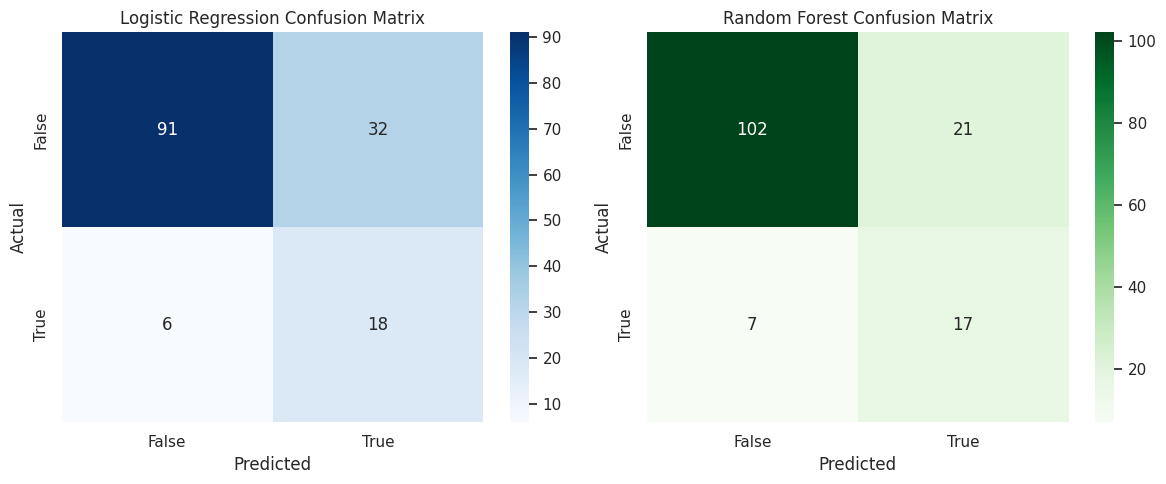

In [24]:
import seaborn as sns

def plot_cm_comparison(y_true_lr,y_true_rf, y_pred_lr, y_pred_rf):
    cm_lr = confusion_matrix(y_true_lr, y_pred_lr)
    cm_rf = confusion_matrix(y_true_rf, y_pred_rf)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Logistic Regression CM
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['False', 'True'], yticklabels=['False', 'True'])
    ax[0].set_title('Logistic Regression Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # Random Forest CM
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax[1],
                xticklabels=['False', 'True'], yticklabels=['False', 'True'])
    ax[1].set_title('Random Forest Confusion Matrix')
    ax[1].set_xlabel('Predicted')
    ax[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

plot_cm_comparison(y_test_lr,y_test_rf, y_pred_lr, y_pred_rf)

### 3.3 特徵相關性分析 (Correlation Heatmap)

計算所有特徵與目標變數 `Attrition` 的相關性，並由高到低排序，以熱圖呈現哪些因素最直接影響離職。

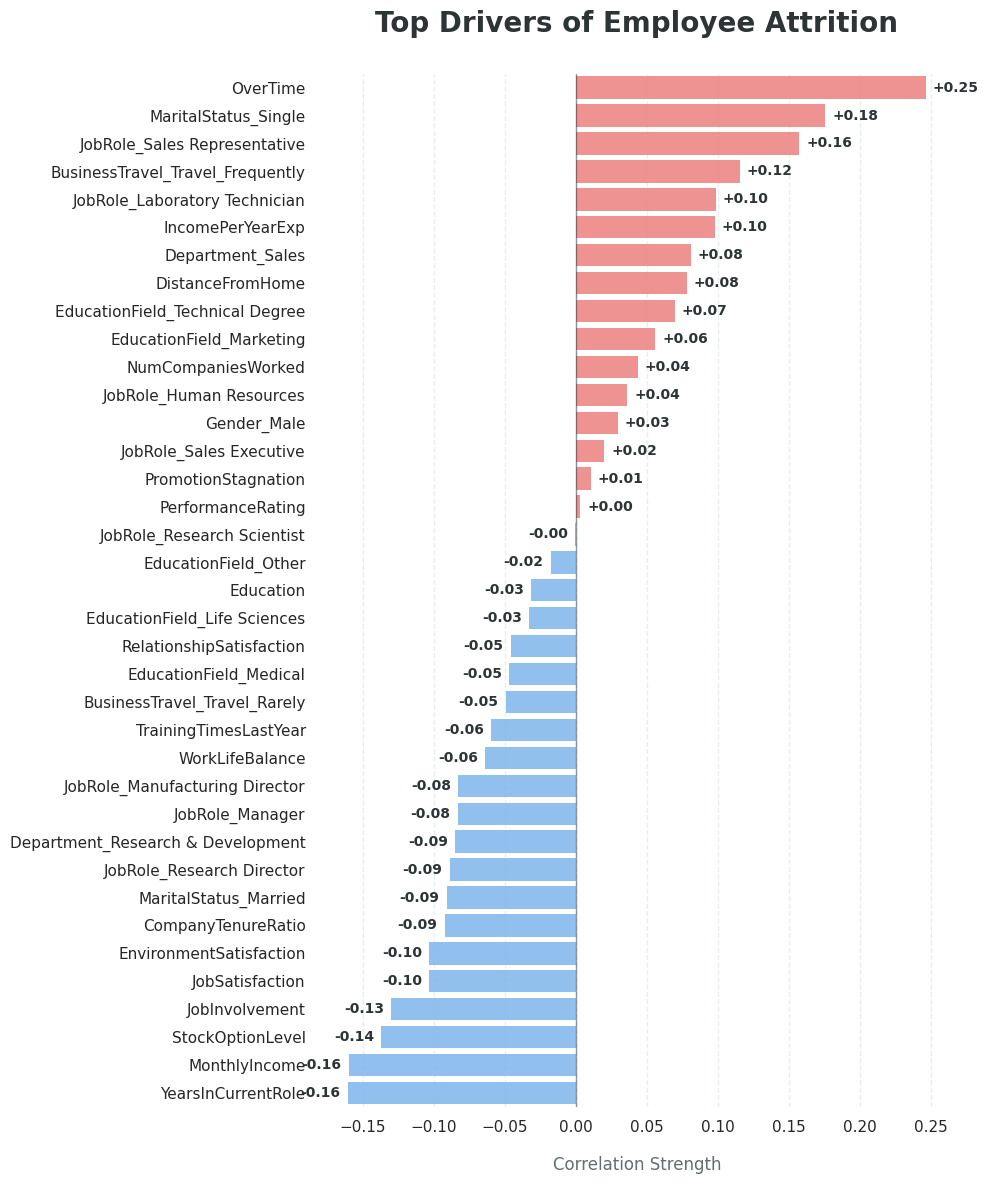

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 數據準備
correlations = df.corr()['Attrition'].sort_values(ascending=False).drop('Attrition')

# 2. 設定極致簡約美學風格
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 12), dpi=100)

# 3. 使用較柔和但具對比性的專業配色 (Soft Red & Blue)
colors = ['#ff7675' if x > 0 else '#74b9ff' for x in correlations.values]

# 4. 繪製條形圖
sns.barplot(
    x=correlations.values,
    y=correlations.index,
    palette=colors,
    edgecolor='none', # 移除邊框更顯現代感
    alpha=0.9,
    ax=ax
)

# 5. 精緻化排版與裝飾
ax.axvline(x=0, color='#2d3436', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('Top Drivers of Employee Attrition', fontsize=20, fontweight='bold', pad=30, color='#2d3436')
ax.set_xlabel('Correlation Strength', fontsize=12, labelpad=15, color='#636e72')
ax.set_ylabel('', fontsize=12)

# 優化網格：只保留垂直的淡灰色網格
ax.xaxis.grid(True, linestyle='--', which='major', color='#dfe6e9', alpha=0.7)
ax.set_axisbelow(True)

# 添加數值標籤，改用更簡潔的呈現方式
for i, v in enumerate(correlations.values):
    ha = 'left' if v > 0 else 'right'
    offset = 0.005 if v > 0 else -0.005
    ax.text(v + offset, i, f'{v:+.2f}',
            va='center', ha=ha, fontsize=10,
            fontweight='bold', color='#2d3436')

# 移除多餘的刻度線與邊框
sns.despine(left=True, bottom=True)
plt.tick_params(axis='both', which='both', bottom=False, left=False)

plt.tight_layout()
plt.show()

In [42]:
#打包訓練好的模型
import joblib
joblib.dump(automl_lr, 'model_lr.pkl')
joblib.dump(automl_rf, 'model_rf.pkl')

['model_rf.pkl']